# MaxCut using QAOA (Qiskit)

## Introduction

The **MaxCut problem** is a classical NP-hard combinatorial optimization problem with significant applications in network design, circuit layout, statistical physics, and machine learning. Given an undirected graph, the objective is to partition vertices into two disjoint sets such that the number of edges crossing between the sets is maximized.

In this notebook, we implement the **Quantum Approximate Optimization Algorithm (QAOA)** to solve MaxCut using Qiskit. QAOA, introduced by Farhi et al. (2014), is a hybrid quantum-classical variational algorithm specifically designed for combinatorial optimization problems. It represents one of the most promising near-term applications of quantum computing.

### Key Concepts:
- **MaxCut Formulation**: We encode the problem as a cost Hamiltonian with Pauli-Z operators
- **QAOA Structure**: The algorithm alternates between problem and mixer Hamiltonians
- **Variational Optimization**: Classical optimizer searches for optimal circuit parameters
- **Quantum Advantage**: QAOA potentially offers advantages for specific problem instances

**Reference**: For detailed problem formulation and theory, see [IBM Quantum Learning](https://quantum.cloud.ibm.com/learning/en/courses/variational-algorithm-design/examples-and-applications)

#### Note: Adiabatic Quantum Computing Connection

**Adiabatic Theorem**: A quantum system starting in the ground state of H₀ remains in the ground state of H(t) if H(t) evolves sufficiently slowly from H₀ to H₁.

**QAOA Approximation**: Instead of continuous slow evolution, QAOA uses discrete steps with optimized parameters, making it practical for NISQ devices with limited coherence times.

---

In [ ]:
## Import reuqisite libraries

import numpy as np
import matplotlib.pyplot as plt
import rustworkx as rx
from rustworkx.visualization import mpl_draw

from qiskit.circuit.library import QAOAAnsatz
from qiskit.quantum_info import SparsePauliOp
from qiskit.result import QuasiDistribution
from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit.primitives import StatevectorSampler as Sampler

from scipy.optimize import minimize

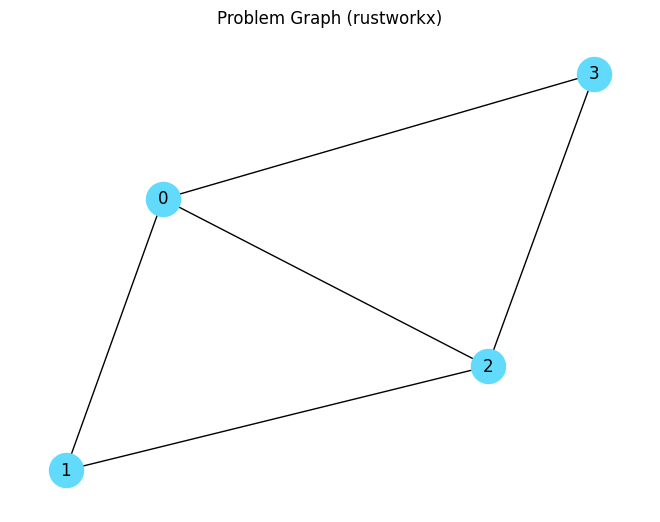

In [9]:
# Create a 4-node graph with 5 edges using rustworkx
n = 4
graph = rx.PyGraph()
graph.add_nodes_from(range(n))
edges = [(0, 1, 1.0), (0, 2, 1.0), (0, 3, 1.0), (1, 2, 1.0), (2, 3, 1.0)]
graph.add_edges_from(edges)

# Using a seed makes the layout consistent across notebook restarts.
pos = rx.spring_layout(graph, seed=123)

# Visualization
mpl_draw(graph, pos=pos, with_labels=True, node_color='#61dafb', node_size=600)
plt.title("Problem Graph (rustworkx)")
plt.show()

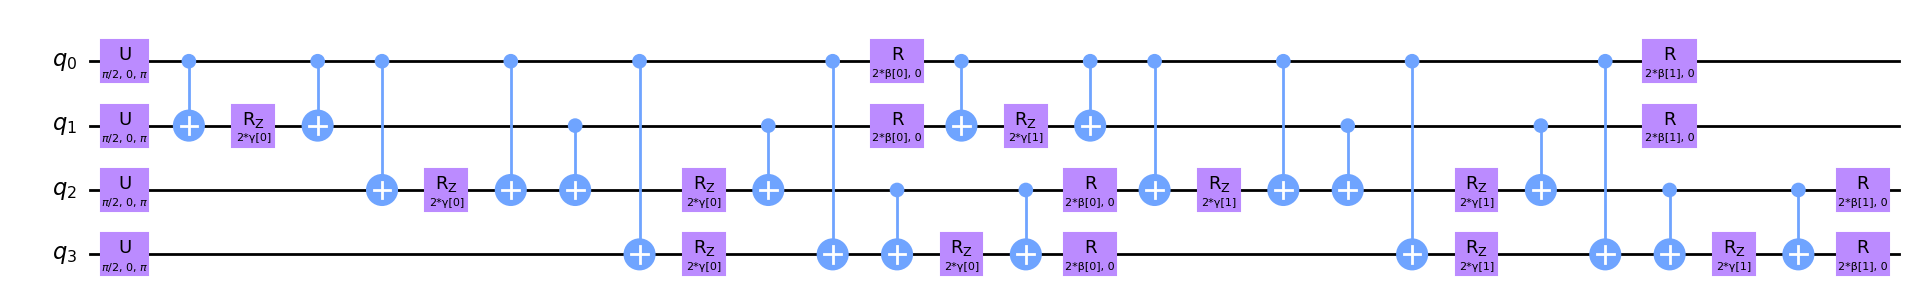

In [ ]:
# Construct the sparse Pauli operator
max_hamiltonian = SparsePauliOp.from_list(
    [("IIZZ", 1), ("IZIZ", 1), ("IZZI", 1), ("ZIIZ", 1), ("ZZII", 1)]
)
 
 
max_ansatz = QAOAAnsatz(max_hamiltonian, reps=2)
# Draw
max_ansatz.decompose(reps=3).draw("mpl", fold=-1, style="clifford")

In [ ]:
# Calculate offset: Sum the weights, and divide by 2
 
offset = -sum(edge[2] for edge in edges) / 2
print(f"""Offset: {offset}""")

Offset: -2.5


In [15]:
def cost_func(params, ansatz, hamiltonian, estimator):
    """Return estimate of energy from estimator
 
    Parameters:
        params (ndarray): Array of ansatz parameters
        ansatz (QuantumCircuit): Parameterized ansatz circuit
        hamiltonian (SparsePauliOp): Operator representation of Hamiltonian
        estimator (Estimator): Estimator primitive instance
 
    Returns:
        float: Energy estimate
    """
    pub = (ansatz, hamiltonian, params)
    cost = estimator.run([pub]).result()[0].data.evs
    #    cost = estimator.run(ansatz, hamiltonian, parameter_values=params).result().values[0]
    return cost

In [ ]:
estimator = Estimator()
sampler = Sampler()

# Set initial parameters
x0 = 2 * np.pi * np.random.rand(max_ansatz.num_parameters)
print(x0)

[4.30104044 2.98655029 4.80033395 3.6162362 ]


In [ ]:
# Run optimization
result = minimize(
    cost_func, x0, args=(max_ansatz, max_hamiltonian, estimator), method="COBYLA"
)

c:\Users\uthupku\OneDrive - Tecnotree\Personal_TT\Learning\Quant\Qiskit\QAMP\codebase\.qcenv\Lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
c:\Users\uthupku\OneDrive - Tecnotree\Personal_TT\Learning\Quant\Qiskit\QAMP\codebase\.qcenv\Lib\site-packages\scipy\sparse\linalg\_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
c:\Users\uthupku\OneDrive - Tecnotree\Personal_TT\Learning\Quant\Qiskit\QAMP\codebase\.qcenv\Lib\site-packages\scipy\sparse\_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


In [22]:
print(result)

 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -1.7832117719818625
       x: [ 5.470e+00  4.271e+00  4.455e+00  3.845e+00]
    nfev: 132
   maxcv: 0.0


In [23]:
eigenvalue = cost_func(result.x, max_ansatz, max_hamiltonian, estimator)
print(f"""Eigenvalue: {eigenvalue}""")
print(f"""Max-Cut Objective: {eigenvalue + offset}""")

Eigenvalue: -1.7832117719818625
Max-Cut Objective: -4.283211771981863


In [24]:
# Assign solution parameters to ansatz
qc = max_ansatz.assign_parameters(result.x)
 
# Add measurements to our circuit
qc.measure_all()
 
# Sample ansatz at optimal parameters
# samp_dist = sampler.run(qc).result().quasi_dists[0]
 
shots = 1024
job = sampler.run([qc], shots=shots)

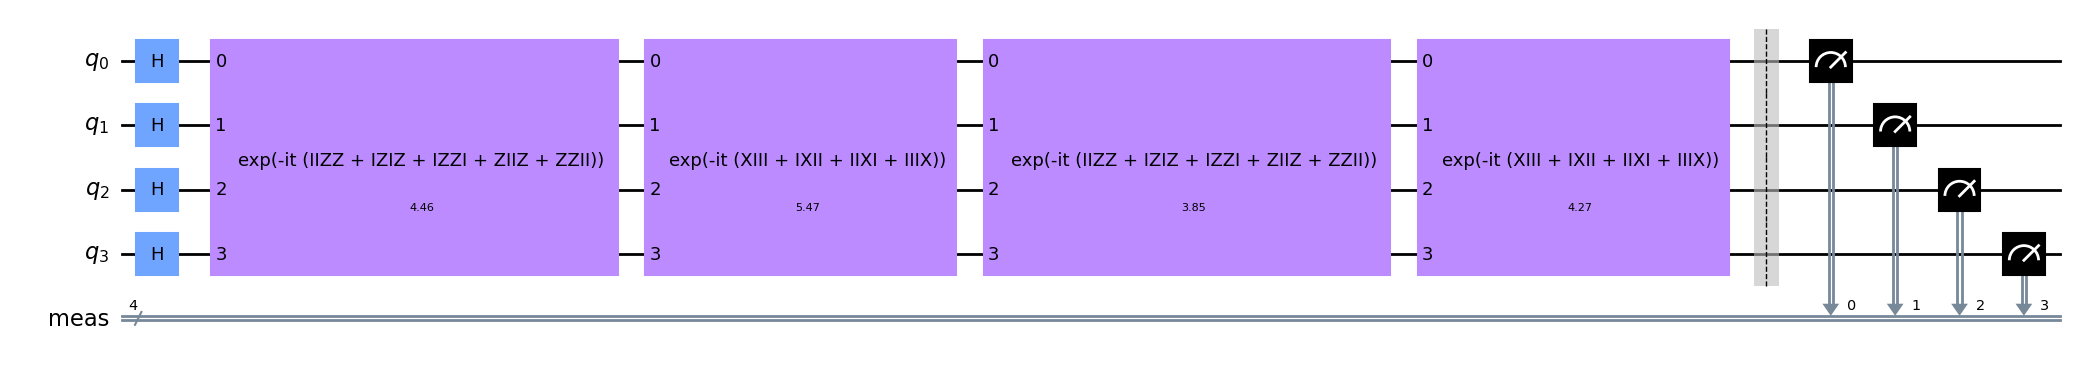

In [26]:
qc.decompose().draw("mpl", fold=-1, style="clifford")

In [ ]:
data_pub = job.result()[0].data
bitstrings = data_pub.meas.get_bitstrings()
counts = data_pub.meas.get_counts()
quasi_dist = QuasiDistribution(
    {outcome: freq / shots for outcome, freq in counts.items()}
)
probabilities = quasi_dist

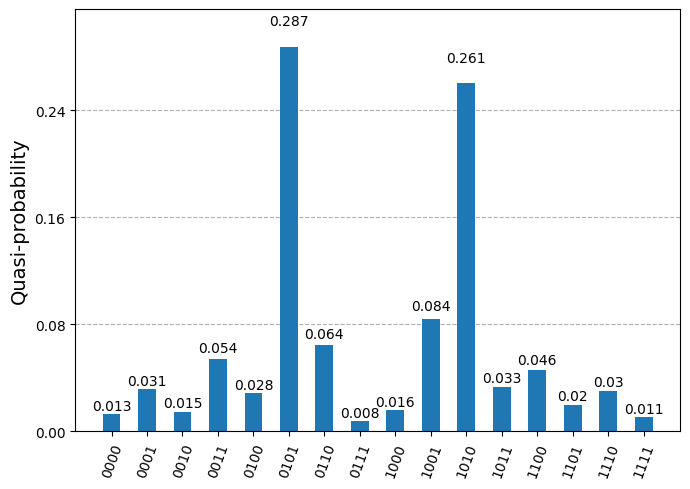

In [ ]:
from qiskit.visualization import plot_distribution

plot_distribution(counts)

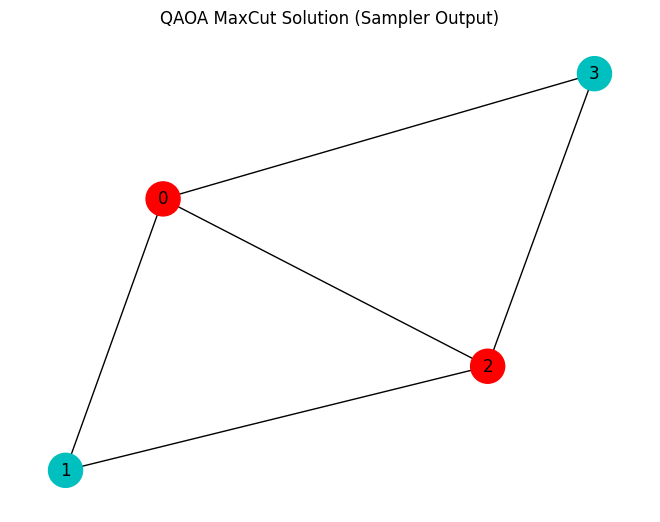

In [ ]:
# Visualize the MaxCut Partition

# Extract most probable bitstring (MaxCut solution)
binary_string = max(counts.items(), key=lambda kv: kv[1])[0]

# Reverse due to Qiskit little-endian convention
x = np.asarray([int(bit) for bit in reversed(binary_string)])

# Assign colors based on partition
colors = ["r" if x[i] == 0 else "c" for i in range(n)]

pos = rx.spring_layout(graph, seed=123)

mpl_draw(
    graph,
    pos=pos,
    with_labels=True,
    node_color=colors,
    node_size=600
)

plt.title("QAOA MaxCut Solution (Sampler Output)")
plt.show()


## Conclusion

### Key Findings

1. **Convergence**: COBYLA successfully converged after 132 function evaluations, with trust region reaching lower bound

2. **Solution Quality**: The algorithm identified the correct MaxCut partition with highest probability among all measurement outcomes
